In [9]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chik0di/board-games-dataset-complete-features")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'board-games-dataset-complete-features' dataset.
Path to dataset files: /kaggle/input/board-games-dataset-complete-features


In [11]:
import os

# listar os arquivos dentro da pasta do dataset
print(os.listdir(path))

['boardgamegeek.json', 'boardgame-geek-dataset_organized.csv']


In [19]:
df = pd.read_csv(path + "/boardgame-geek-dataset_organized.csv")
print("Primeiras 5 linhas do dataset:")
df.head()

Primeiras 5 linhas do dataset:


,row_id,boardgame,release_year,min_players,max_players,min_playtime,max_playtime,minimum_age,avg_rating,num_ratings,...,rank_strategy,rank_thematic,rank_family,rank_war,rank_customizable,rank_abstract,rank_party,rank_childrens,url,description
0,1,Brass: Birmingham,2018,2,4,60,120,14,8.575,53548,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/224517/bra...,"Build networks, grow industries, and navigate ..."
1,2,Pandemic Legacy: Season 1,2015,2,4,60,60,13,8.512,56071,...,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/161936/pan...,Mutating diseases are spreading around the wor...
2,3,Ark Nova,2021,1,4,90,150,14,8.539,54528,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/342942/ark...,"Plan and build a modern, scientifically manage..."
3,4,Gloomhaven,2017,1,4,60,120,14,8.557,65443,...,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/174430/glo...,Vanquish monsters with strategic cardplay. Ful...
4,5,Twilight Imperium: Fourth Edition,2017,3,6,240,480,14,8.572,26686,...,5.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/233078/twi...,"Build an intergalactic empire through trade, r..."


In [21]:
print("Primeiras 5 linhas do dataset:")
print(df.head())

Primeiras 5 linhas do dataset:
   row_id                          boardgame  release_year  min_players  \
0       1                  Brass: Birmingham          2018            2   
1       2          Pandemic Legacy: Season 1          2015            2   
2       3                           Ark Nova          2021            1   
3       4                         Gloomhaven          2017            1   
4       5  Twilight Imperium: Fourth Edition          2017            3   

   max_players  min_playtime  max_playtime  minimum_age  avg_rating  \
0            4            60           120           14       8.575   
1            4            60            60           13       8.512   
2            4            90           150           14       8.539   
3            4            60           120           14       8.557   
4            6           240           480           14       8.572   

   num_ratings  ...  rank_strategy  rank_thematic  rank_family  rank_war  \
0        53548 

In [24]:
# Tipos de dados de cada coluna
print("Tipos de dados de cada coluna:")
print(df.info())

Tipos de dados de cada coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 57 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             2000 non-null   int64  
 1   boardgame          2000 non-null   object 
 2   release_year       2000 non-null   int64  
 3   min_players        2000 non-null   int64  
 4   max_players        2000 non-null   int64  
 5   min_playtime       2000 non-null   int64  
 6   max_playtime       2000 non-null   int64  
 7   minimum_age        2000 non-null   int64  
 8   avg_rating         2000 non-null   float64
 9   num_ratings        2000 non-null   int64  
 10  complexity         2000 non-null   float64
 11  rank_overall       2000 non-null   int64  
 12  owned              2000 non-null   int64  
 13  wishlisted         2000 non-null   int64  
 14  total_plays        2000 non-null   int64  
 15  fans               2000 non-null   int64 

In [28]:
# Estatísticas descritiva da coluna average_rating:
print(df['avg_rating'].describe())
# Tempo medio do jogo de tabuleiro é de: 7.420455 ou 7.4.

count    2000.000000
mean        7.420455
std         0.439694
min         6.457000
25%         7.098000
50%         7.384000
75%         7.683000
max         9.158000
Name: avg_rating, dtype: float64


In [31]:
df['playing_time'] = (df['min_playtime'] + df['max_playtime']) / 2
# Estatísticas descritiva da coluna average_rating:
print(df['playing_time'].describe())
# O tempo de jogo médio é: 73.109000
# o desvio padrão de: 62.951669

count    2000.000000
mean       73.109000
std        62.951669
min         0.000000
25%        37.500000
50%        60.000000
75%        90.000000
max       660.000000
Name: playing_time, dtype: float64


In [34]:
print(df['avg_rating'].isna().sum())

0


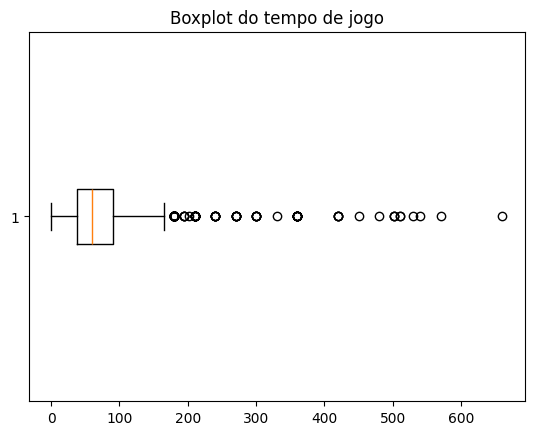

In [37]:
plt.boxplot(df['playing_time'].dropna(), vert=False)
plt.title('Boxplot do tempo de jogo')
plt.show()

In [39]:
print("Q1: ", df['playing_time'].quantile(0.25))
print("Q2: ", df['playing_time'].quantile(0.50))
print("Q3: ", df['playing_time'].quantile(0.75))
print("IQR: ", df['playing_time'].quantile(0.75) - df['playing_time'].quantile(0.25))

# Limites para outliers
limite_inferior = df['playing_time'].quantile(0.25) - 1.5 * df['playing_time'].quantile(0.75) - df['playing_time'].quantile(0.25)
limite_superior = df['playing_time'].quantile(0.75) + 1.5 * df['playing_time'].quantile(0.75)

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

# Filtrar os outliers
outliers = df[(df['playing_time'] < limite_inferior) | (df['playing_time'] > limite_superior)]

print("Quantidade de outliers:", outliers.shape[0])

Q1:  37.5
Q2:  60.0
Q3:  90.0
IQR:  52.5
Limite inferior: -135.0
Limite superior: 225.0
Quantidade de outliers: 48


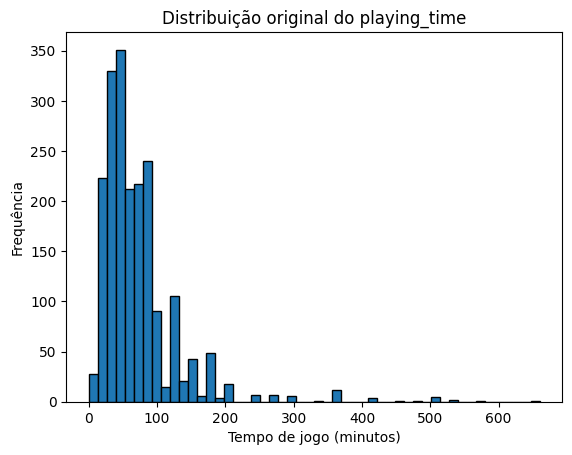

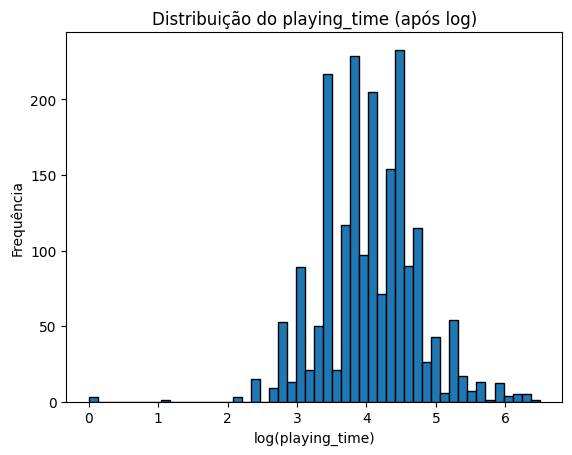

In [43]:
# Histograma original
plt.hist(df['playing_time'], bins=50, edgecolor='black')
plt.title("Distribuição original do playing_time")
plt.xlabel("Tempo de jogo (minutos)")
plt.ylabel("Frequência")
plt.show()

# Transformação logarítmica de playing_time
df['playing_time_log'] = np.log1p(df['playing_time'])

# Histograma após transformação logarítmica
plt.hist(df['playing_time_log'], bins=50, edgecolor='black')
plt.title("Distribuição do playing_time (após log)")
plt.xlabel("log(playing_time)")
plt.ylabel("Frequência")
plt.show()

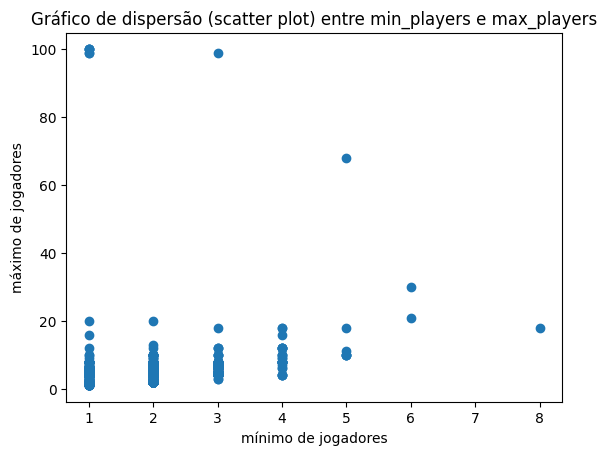

In [44]:
# Grafico (scatter plot) de dispersão com min e max de jogadores
plt.scatter(df['min_players'], df['max_players'])
plt.title('Gráfico de dispersão (scatter plot) entre min_players e max_players')
plt.xlabel('mínimo de jogadores')
plt.ylabel('máximo de jogadores')
plt.show()

# Quanto maior o numerio mínimo de jogadores, o numero máximo tende a ser maior.

In [58]:
# Calculo da matriz de correlação do DataFrame
correlacao = df.corr(numeric_only=True)
print(correlacao)

                     row_id  release_year  min_players  max_players  \
row_id             1.000000     -0.014429     0.043090     0.005884   
release_year      -0.014429      1.000000    -0.068804    -0.181897   
min_players        0.043090     -0.068804     1.000000     0.098884   
max_players        0.005884     -0.181897     0.098884     1.000000   
min_playtime      -0.037907      0.005583     0.021599    -0.039336   
max_playtime      -0.060282      0.003039    -0.104290    -0.038726   
minimum_age       -0.179940      0.119558    -0.141552    -0.097742   
avg_rating        -0.477495      0.060397    -0.254746    -0.044696   
num_ratings       -0.509106     -0.030488     0.076977     0.035725   
complexity        -0.222102      0.004491    -0.231912    -0.116246   
rank_overall       0.999998     -0.014435     0.043144     0.005868   
owned             -0.487035     -0.021210     0.049335     0.035908   
wishlisted        -0.645814      0.033893    -0.074385     0.001178   
total_

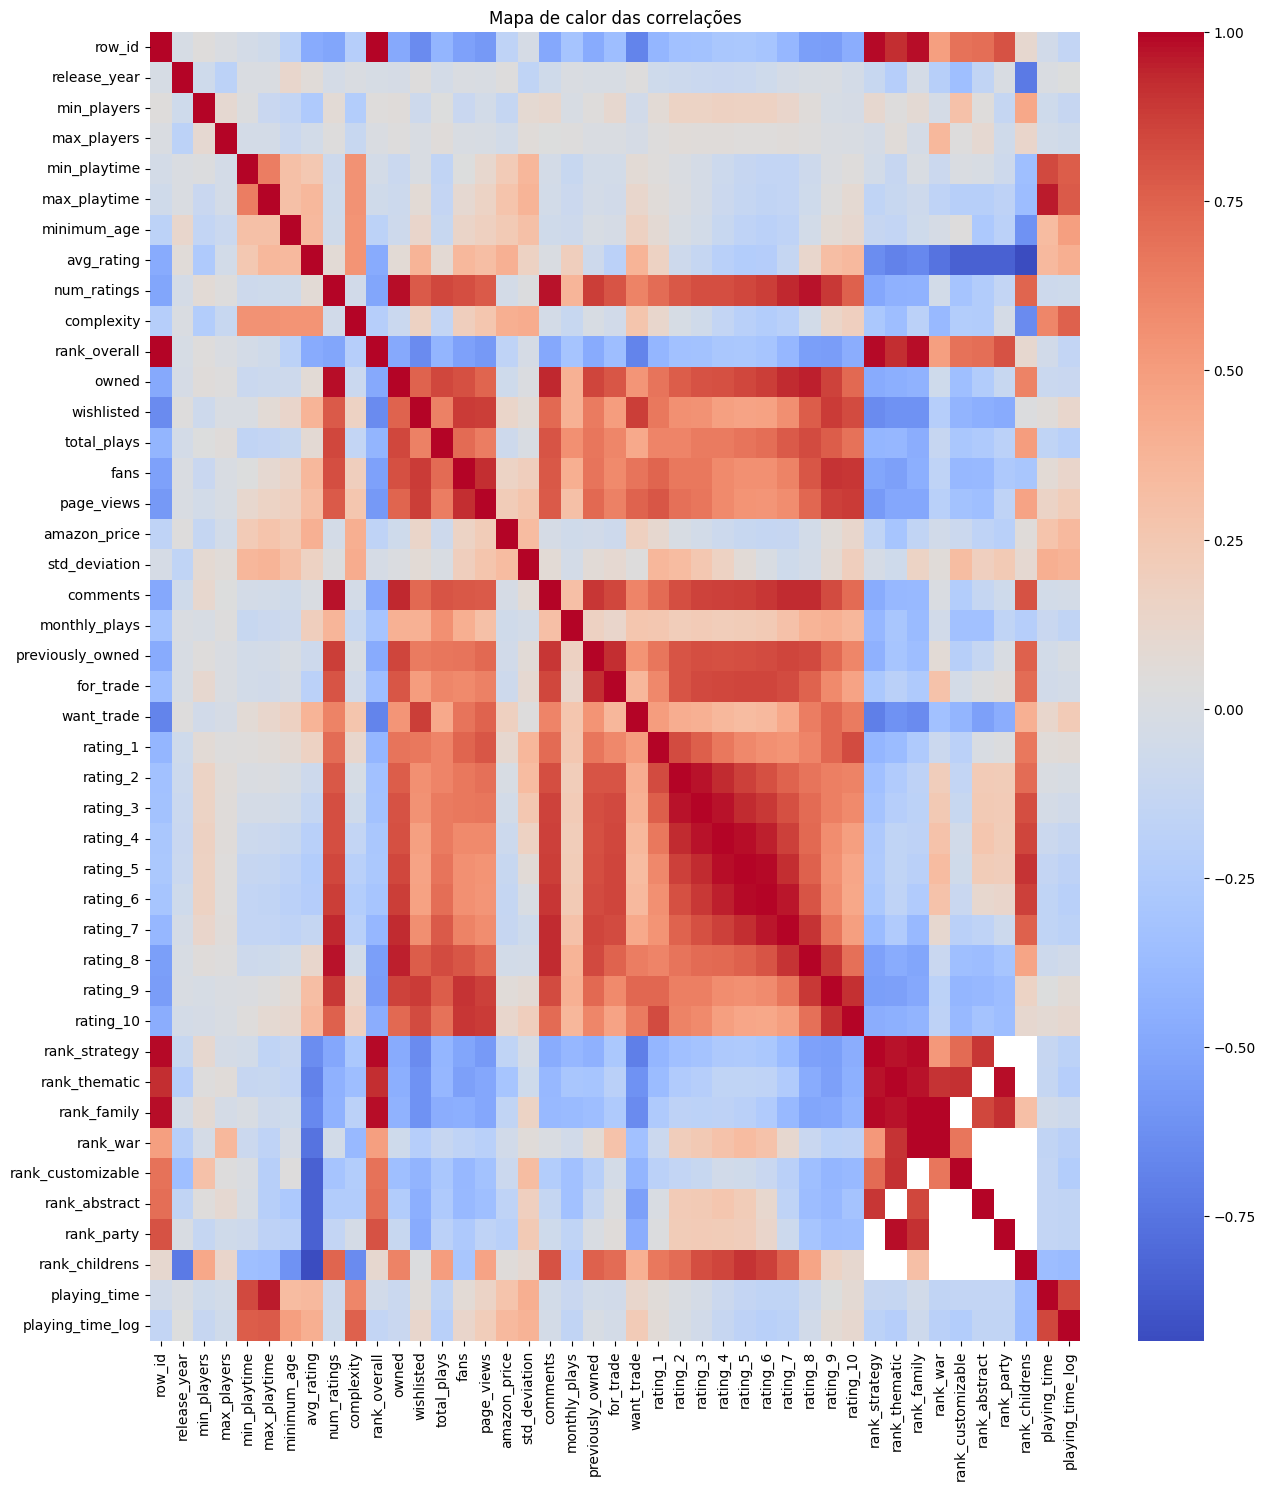

In [66]:
# Mapa de calor para vizualizar a matriz de correlação
plt.figure(figsize=(15, 17))
sns.heatmap(correlacao, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor das correlações")
plt.show()

In [68]:
# Identificar a coluna que representa a data de publicação do jogo (yearpublished) ano publicação.
print(df['release_year'].head())

0    2018
1    2015
2    2021
3    2017
4    2017
Name: release_year, dtype: int64


In [70]:
# Criação da coluna decada
df['Decada'] = (df['release_year'] // 10) * 10

In [71]:
# Contagem de jogos por decada
print("Jogos por década:")
print(df['Decada'].value_counts().sort_index)

Jogos por década:
<bound method Series.sort_index of Decada
2010    1031
2020     567
2000     280
1990      74
1980      25
1970       9
0          3
1960       2
1870       1
1470       1
1630       1
1950       1
1800       1
1850       1
1920       1
1810       1
1580       1
Name: count, dtype: int64>


In [76]:
# A década com o maior número de lançamento e quantidade de jogos lançados
print("A década com o maior número de lançamento:")
print(df['Decada'].value_counts().idxmax())
print("Quantidade de jogos lançados:")
print(df['Decada'].value_counts().max())

A década com o maior número de lançamento:
2010
Quantidade de jogos lançados:
1031
